# Modeling
## ID/X Partners Credit Risk Prediction

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook builds and evaluates multiple machine learning models to predict credit risk
using the cleaned dataset prepared in `Data_Cleaning_Handling.ipynb`. The goal is to identify
the best performing model for predicting loan default while ensuring reliable performance
on unseen data.

---

## 🎯 Objectives
- Train and evaluate 6 machine learning models for default prediction
- Compare model performance across multiple evaluation metrics
- Identify the most important features driving default risk
- Select the best model for the final prediction phase

---

## 🔍 Analysis Scope
The analysis includes:
- Class imbalance handling using `class_weight='balanced'` and `scale_pos_weight`
- Model training for Logistic Regression, Decision Tree, Random Forest, KNN, XGBoost, LightGBM
- Comprehensive evaluation: Confusion Matrix, Classification Report, and ROC-AUC
- Model comparison across all metrics for final model selection

---

## 🧠 Key Questions
- Which model performs best for predicting loan default?
- What are the strongest predictors of default risk?
- How does each model balance precision and recall for the minority class?
- What business insights can be derived from model results?

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- LightGBM

---

## 📊 Output
The output of this notebook will serve as:
- A trained and evaluated credit risk prediction model
- Model performance comparison for final model selection
- Feature importance rankings for business interpretation
- Input for the final prediction phase

# Importing Library

In [1]:
# Installation Library
!pip install seaborn scikit-learn lightgbm xgboost catboost shap imbalanced-learn 


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Install optuna
!pip install optuna


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import joblib

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import lightgbm as lgb
import xgboost as xgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import shap
# Hyperparameter Tunning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Importing Dataset

In [4]:
# Load train and test sets
train_path = r'D:\Python\Projects\Project Idxpartners Credit Risk Prediction Model\Loan_Credit_Risk_Prediction\train_set.csv'
test_path = r'D:\Python\Projects\Project Idxpartners Credit Risk Prediction Model\Loan_Credit_Risk_Prediction\test_set.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# Separate features and target
X_train = train.drop(columns=['is_default'])
y_train = train['is_default']

X_test = test.drop(columns=['is_default'])
y_test = test['is_default']

print(f"Train set: {X_train.shape}")
print(f"Test set : {X_test.shape}")
print(f"\nDefault rate (train): {y_train.mean() * 100:.2f}%")
print(f"Default rate (test) : {y_test.mean() * 100:.2f}%")

Train set: (184636, 94)
Test set : (46159, 94)

Default rate (train): 19.09%
Default rate (test) : 19.09%


# Handle Imbalance

The target variable `is_default` shows a moderate class imbalance with **80.91% Good Loan**
and **19.09% Bad Loan** in the training set. If left unaddressed, models tend to be biased
toward the majority class, resulting in poor recall for the minority class (Bad Loan).

The approach includes:
- Using `class_weight='balanced'` for Logistic Regression, Decision Tree, and Random Forest,
  which automatically adjusts weights inversely proportional to class frequencies
- Using `scale_pos_weight` for XGBoost and LightGBM, calculated as the ratio of
  negative to positive class counts
- KNN does not support class weighting natively, but the moderately imbalanced ratio
  of 80:20 is manageable without additional handling

This approach is preferred over SMOTE given the large dataset size (184k rows),
where synthetic oversampling would significantly increase training time without
meaningful performance gains at this imbalance ratio.

In [5]:
# Calculate scale_pos_weight for XGBoost and LightGBM
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative class (Good Loan): {neg:,}")
print(f"Positive class (Bad Loan) : {pos:,}")
print(f"scale_pos_weight          : {scale_pos_weight:.4f}")

Negative class (Good Loan): 149,382
Positive class (Bad Loan) : 35,254
scale_pos_weight          : 4.2373


# 1. Logistic Regression

Logistic Regression is a linear model that estimates the probability of default based on
a weighted combination of input features. It serves as the interpretable baseline model
and is required by the project scope.

## 1.1 Training

In [9]:
# Initialize and train Logistic Regression with class_weight balanced
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train, y_train)
print("Logistic Regression training completed.")

Logistic Regression training completed.


## 1.2 Evaluation

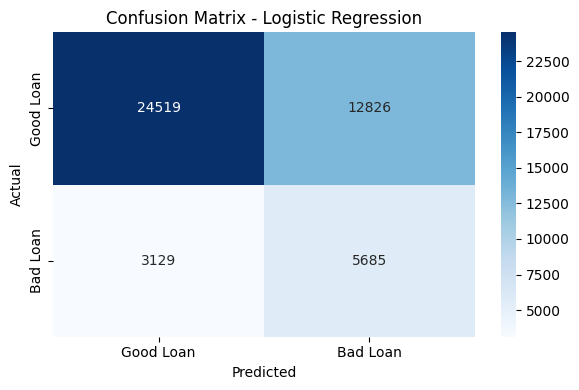

In [10]:
# Predictions
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Loan', 'Bad Loan'],
            yticklabels=['Good Loan', 'Bad Loan'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [11]:
# Classification Report
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_lr, target_names=['Good Loan', 'Bad Loan']))

# ROC-AUC, Gini, KS Statistic
auc_lr = roc_auc_score(y_test, y_prob_lr)
gini_lr = 2 * auc_lr - 1
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
ks_lr = max(tpr_lr - fpr_lr)

print(f"ROC-AUC Score : {auc_lr:.4f}")
print(f"Gini          : {gini_lr:.4f}")
print(f"KS Statistic  : {ks_lr:.4f}")

Classification Report - Logistic Regression
              precision    recall  f1-score   support

   Good Loan       0.89      0.66      0.75     37345
    Bad Loan       0.31      0.64      0.42      8814

    accuracy                           0.65     46159
   macro avg       0.60      0.65      0.59     46159
weighted avg       0.78      0.65      0.69     46159

ROC-AUC Score : 0.7073
Gini          : 0.4145
KS Statistic  : 0.3070


### Key Findings

**Model Performance**
Logistic Regression achieves a ROC-AUC of **0.7073** with a Gini coefficient of **0.4145**
and KS Statistic of **0.3070**, indicating moderate discriminative power as expected
for a linear baseline model.

**Class Imbalance Handling**
`class_weight='balanced'` effectively improved recall for Bad Loan to **0.64**, meaning
the model correctly identifies 64% of actual defaulters. However, precision for Bad Loan
is only **0.31**, indicating a high false positive rate where many good borrowers
are predicted as defaulters.

**Confusion Matrix Insights**
- True Negatives (correctly predicted Good Loan): 24,519
- False Positives (Good Loan predicted as Bad Loan): 12,826
- False Negatives (Bad Loan predicted as Good Loan): 3,129
- True Positives (correctly predicted Bad Loan): 5,685

**Trade-off Observation**
The model prioritizes recall over precision for the Bad Loan class, which is acceptable
in credit risk context where missing a defaulter (False Negative) is more costly than
incorrectly flagging a good borrower (False Positive). However, the low precision (0.31)
may lead to excessive loan rejections.

**Baseline Established**
As a linear model, Logistic Regression serves as the interpretable baseline.
Tree-based ensemble models are expected to outperform this result.

---

# 2. Decision Tree

Decision Tree is a non-linear model that splits data based on feature thresholds
to form a tree-like structure of decisions. It is highly interpretable and serves
as the foundation for ensemble methods like Random Forest.

## 2.1 Training

In [13]:
# Initialize and train Decision Tree with class_weight balanced
dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)
print("Decision Tree training completed.")

Decision Tree training completed.


## 2.2 Evaluation

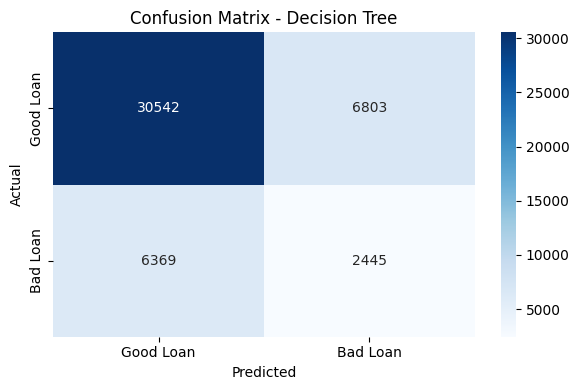

In [14]:
# Predictions
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Loan', 'Bad Loan'],
            yticklabels=['Good Loan', 'Bad Loan'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [15]:
# Classification Report
print("Classification Report - Decision Tree")
print(classification_report(y_test, y_pred_dt, target_names=['Good Loan', 'Bad Loan']))

# ROC-AUC, Gini, KS Statistic
auc_dt = roc_auc_score(y_test, y_prob_dt)
gini_dt = 2 * auc_dt - 1
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
ks_dt = max(tpr_dt - fpr_dt)

print(f"ROC-AUC Score : {auc_dt:.4f}")
print(f"Gini          : {gini_dt:.4f}")
print(f"KS Statistic  : {ks_dt:.4f}")

Classification Report - Decision Tree
              precision    recall  f1-score   support

   Good Loan       0.83      0.82      0.82     37345
    Bad Loan       0.26      0.28      0.27      8814

    accuracy                           0.71     46159
   macro avg       0.55      0.55      0.55     46159
weighted avg       0.72      0.71      0.72     46159

ROC-AUC Score : 0.5476
Gini          : 0.0952
KS Statistic  : 0.0952


### Key Findings

**Model Performance**
Decision Tree achieves a ROC-AUC of **0.5476** with a Gini coefficient of **0.0952**
and KS Statistic of **0.0952**, indicating very weak discriminative power and only
marginally better than a random classifier.

**Confusion Matrix Insights**
- True Negatives (correctly predicted Good Loan): 30,542
- False Positives (Good Loan predicted as Bad Loan): 6,803
- False Negatives (Bad Loan predicted as Good Loan): 6,369
- True Positives (correctly predicted Bad Loan): 2,445

**Weak Default Detection**
Recall for Bad Loan is only **0.28**, meaning the model misses 72% of actual defaulters.
Precision for Bad Loan is also low at **0.26**, confirming the model struggles to
correctly identify default cases in both directions.

**Overfitting Tendency**
Decision Trees are prone to overfitting without depth constraints, which likely explains
the poor generalization on the test set despite reasonable training accuracy.
Ensemble methods are expected to address this limitation.

---

# 3. Random Forest

Random Forest is an ensemble method that builds multiple decision trees on random
subsets of data and features, then aggregates their predictions. It reduces the
overfitting tendency of individual decision trees and generally produces more
robust and stable predictions.

## 3.1 Training

In [16]:
# Initialize and train Random Forest with class_weight balanced
rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest training completed.")

Random Forest training completed.


## 3.2 Evaluation

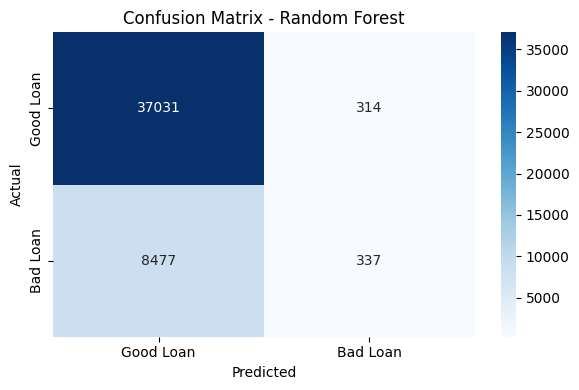

In [17]:
# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Loan', 'Bad Loan'],
            yticklabels=['Good Loan', 'Bad Loan'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [18]:
# Classification Report
print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=['Good Loan', 'Bad Loan']))

# ROC-AUC, Gini, KS Statistic
auc_rf = roc_auc_score(y_test, y_prob_rf)
gini_rf = 2 * auc_rf - 1
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
ks_rf = max(tpr_rf - fpr_rf)

print(f"ROC-AUC Score : {auc_rf:.4f}")
print(f"Gini          : {gini_rf:.4f}")
print(f"KS Statistic  : {ks_rf:.4f}")

Classification Report - Random Forest
              precision    recall  f1-score   support

   Good Loan       0.81      0.99      0.89     37345
    Bad Loan       0.52      0.04      0.07      8814

    accuracy                           0.81     46159
   macro avg       0.67      0.51      0.48     46159
weighted avg       0.76      0.81      0.74     46159

ROC-AUC Score : 0.7039
Gini          : 0.4078
KS Statistic  : 0.2965


### Key Findings

**Model Performance**
Random Forest achieves a ROC-AUC of **0.7039** with a Gini coefficient of **0.4078**
and KS Statistic of **0.2965**, indicating moderate discriminative power comparable
to Logistic Regression despite being a more complex model.

**Confusion Matrix Insights**
- True Negatives (correctly predicted Good Loan): 37,031
- False Positives (Good Loan predicted as Bad Loan): 314
- False Negatives (Bad Loan predicted as Good Loan): 8,477
- True Positives (correctly predicted Bad Loan): 337

**Severely Low Recall for Bad Loan**
Recall for Bad Loan is only **0.04**, meaning the model misses 96% of actual defaulters.
Despite high precision for Bad Loan (0.52), the model is heavily biased toward predicting
Good Loan, making it unreliable for default detection at the default threshold of 0.5.

**Threshold Adjustment Needed**
The extremely low recall suggests the model's predicted probabilities for Bad Loan
are concentrated below 0.5. Lowering the classification threshold would significantly
improve recall at the cost of precision, which is preferable in credit risk context.

**Strong Majority Class Prediction**
The model achieves 99% recall for Good Loan but nearly ignores Bad Loan entirely.
This behavior indicates the model heavily favors the majority class despite
`class_weight='balanced'` being applied.

---

# 4. K-Nearest Neighbors

K-Nearest Neighbors (KNN) is a non-parametric model that classifies a data point
based on the majority class of its K nearest neighbors in the feature space.
It requires no training phase but is sensitive to feature scaling and
computationally expensive on large datasets.

## 4.1 Training

In [21]:
# Initialize and train KNN
knn = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn.fit(X_train, y_train)
print("KNN training completed.")

KNN training completed.


## 4.2 Evaluation

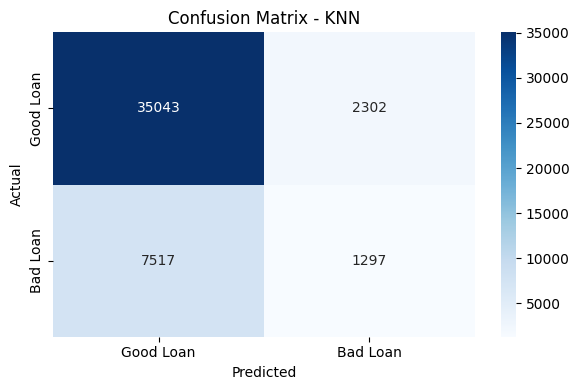

In [22]:
# Predictions
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Loan', 'Bad Loan'],
            yticklabels=['Good Loan', 'Bad Loan'])
plt.title('Confusion Matrix - KNN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [23]:
# Classification Report
print("Classification Report - KNN")
print(classification_report(y_test, y_pred_knn, target_names=['Good Loan', 'Bad Loan']))

# ROC-AUC, Gini, KS Statistic
auc_knn = roc_auc_score(y_test, y_prob_knn)
gini_knn = 2 * auc_knn - 1
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
ks_knn = max(tpr_knn - fpr_knn)

print(f"ROC-AUC Score : {auc_knn:.4f}")
print(f"Gini          : {gini_knn:.4f}")
print(f"KS Statistic  : {ks_knn:.4f}")

Classification Report - KNN
              precision    recall  f1-score   support

   Good Loan       0.82      0.94      0.88     37345
    Bad Loan       0.36      0.15      0.21      8814

    accuracy                           0.79     46159
   macro avg       0.59      0.54      0.54     46159
weighted avg       0.73      0.79      0.75     46159

ROC-AUC Score : 0.6197
Gini          : 0.2394
KS Statistic  : 0.1811


### Key Findings

**Model Performance**
KNN achieves a ROC-AUC of **0.6197** with a Gini coefficient of **0.2394**
and KS Statistic of **0.1811**, indicating below-average discriminative power
for a credit risk prediction task.

**Confusion Matrix Insights**
- True Negatives (correctly predicted Good Loan): 35,043
- False Positives (Good Loan predicted as Bad Loan): 2,302
- False Negatives (Bad Loan predicted as Good Loan): 7,517
- True Positives (correctly predicted Bad Loan): 1,297

**Low Recall for Bad Loan**
Recall for Bad Loan is only **0.15**, meaning the model misses 85% of actual defaulters.
KNN's inability to handle class imbalance natively contributes to this poor recall,
as the model is naturally biased toward the majority class without class weight support.

**Computational Limitation**
KNN is fundamentally a distance-based lazy learner that struggles with large datasets
and high-dimensional feature spaces. With 94 features and 184k training samples,
the model's performance is constrained by the curse of dimensionality.

**Not Recommended for Production**
Given the low ROC-AUC and poor recall for Bad Loan, KNN is not suitable
for this credit risk prediction task and will not be considered for final model selection.

---

# 5. XGBoost

XGBoost is a gradient boosting framework that builds trees sequentially, where each
tree corrects the errors of the previous one. It is known for its high performance,
speed, and built-in regularization, making it one of the most effective algorithms
for structured tabular data.

## 5.1 Training

In [26]:
# Initialize and train XGBoost with scale_pos_weight for class imbalance
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=0
)

xgb_model.fit(X_train, y_train)
print("XGBoost training completed.")

XGBoost training completed.


## 5.2 Evaluation

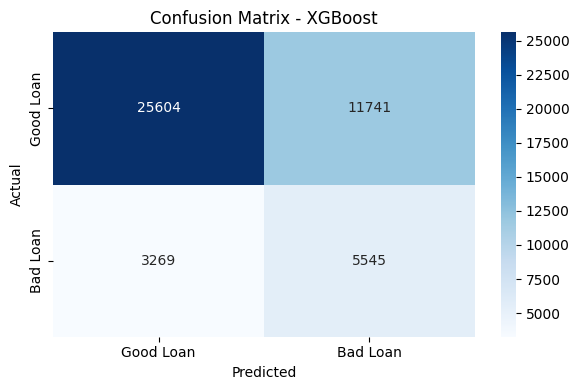

In [27]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Loan', 'Bad Loan'],
            yticklabels=['Good Loan', 'Bad Loan'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [28]:
# Classification Report
print("Classification Report - XGBoost")
print(classification_report(y_test, y_pred_xgb, target_names=['Good Loan', 'Bad Loan']))

# ROC-AUC, Gini, KS Statistic
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
gini_xgb = 2 * auc_xgb - 1
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
ks_xgb = max(tpr_xgb - fpr_xgb)

print(f"ROC-AUC Score : {auc_xgb:.4f}")
print(f"Gini          : {gini_xgb:.4f}")
print(f"KS Statistic  : {ks_xgb:.4f}")

Classification Report - XGBoost
              precision    recall  f1-score   support

   Good Loan       0.89      0.69      0.77     37345
    Bad Loan       0.32      0.63      0.42      8814

    accuracy                           0.67     46159
   macro avg       0.60      0.66      0.60     46159
weighted avg       0.78      0.67      0.71     46159

ROC-AUC Score : 0.7120
Gini          : 0.4241
KS Statistic  : 0.3171


### Key Findings

**Model Performance**
XGBoost achieves a ROC-AUC of **0.7120** with a Gini coefficient of **0.4241**
and KS Statistic of **0.3171**, indicating moderate-to-good discriminative power
and the strongest performance among all models trained so far.

**Confusion Matrix Insights**
- True Negatives (correctly predicted Good Loan): 25,604
- False Positives (Good Loan predicted as Bad Loan): 11,741
- False Negatives (Bad Loan predicted as Good Loan): 3,269
- True Positives (correctly predicted Bad Loan): 5,545

**Balanced Default Detection**
Recall for Bad Loan reaches **0.63**, meaning the model correctly identifies 63% of
actual defaulters. Combined with the ROC-AUC of 0.7120, XGBoost demonstrates
a better balance between detecting defaults and minimizing false alarms
compared to Random Forest and KNN.

**Effect of scale_pos_weight**
The `scale_pos_weight` parameter effectively shifted the model's attention toward
the minority class, resulting in recall for Bad Loan comparable to Logistic Regression
while maintaining stronger overall discriminative power.

**Room for Improvement**
XGBoost is currently trained with default parameters. Hyperparameter tuning on
`max_depth`, `learning_rate`, and `n_estimators` is expected to further improve performance.

---

# 6. LightGBM

LightGBM is a gradient boosting framework that uses a leaf-wise tree growth strategy
instead of the level-wise approach used by XGBoost. It is designed for speed and
efficiency on large datasets while maintaining high predictive performance.

## 6.1 Training

In [31]:
# Initialize and train LightGBM with scale_pos_weight for class imbalance
lgbm = LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm.fit(X_train, y_train)
print("LightGBM training completed.")

LightGBM training completed.


## 6.2 Evaluation

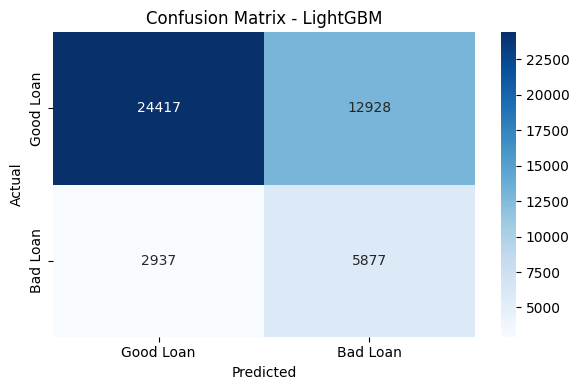

In [32]:
# Predictions
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Loan', 'Bad Loan'],
            yticklabels=['Good Loan', 'Bad Loan'])
plt.title('Confusion Matrix - LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [33]:
# Classification Report
print("Classification Report - LightGBM")
print(classification_report(y_test, y_pred_lgbm, target_names=['Good Loan', 'Bad Loan']))

# ROC-AUC, Gini, KS Statistic
auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)
gini_lgbm = 2 * auc_lgbm - 1
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
ks_lgbm = max(tpr_lgbm - fpr_lgbm)

print(f"ROC-AUC Score : {auc_lgbm:.4f}")
print(f"Gini          : {gini_lgbm:.4f}")
print(f"KS Statistic  : {ks_lgbm:.4f}")

Classification Report - LightGBM
              precision    recall  f1-score   support

   Good Loan       0.89      0.65      0.75     37345
    Bad Loan       0.31      0.67      0.43      8814

    accuracy                           0.66     46159
   macro avg       0.60      0.66      0.59     46159
weighted avg       0.78      0.66      0.69     46159

ROC-AUC Score : 0.7180
Gini          : 0.4360
KS Statistic  : 0.3229


### Key Findings

**Model Performance**
LightGBM achieves a ROC-AUC of **0.7180** with a Gini coefficient of **0.4360**
and KS Statistic of **0.3229**, the strongest discriminative performance among
all six models trained in this project.

**Confusion Matrix Insights**
- True Negatives (correctly predicted Good Loan): 24,417
- False Positives (Good Loan predicted as Bad Loan): 12,928
- False Negatives (Bad Loan predicted as Good Loan): 2,937
- True Positives (correctly predicted Bad Loan): 5,877

**Best Recall for Bad Loan**
Recall for Bad Loan reaches **0.67**, the highest among all models, meaning LightGBM
correctly identifies 67% of actual defaulters. This makes it the most reliable model
for minimizing missed defaults, which is the primary concern in credit risk prediction.

**Precision-Recall Trade-off**
Precision for Bad Loan is **0.31**, consistent with other models that prioritize recall.
The F1-score of 0.43 reflects a reasonable balance given the class imbalance in the dataset.

**Speed and Efficiency**
LightGBM's leaf-wise growth strategy delivers the best ROC-AUC while remaining
computationally efficient, making it well-suited for large-scale credit risk datasets.

---

# 7. Model Comparison

This section compares all six models across key evaluation metrics to identify
the best performing model for credit default prediction.

In [34]:
# Compile all metrics into a comparison table
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'XGBoost',
        'LightGBM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    'Precision (Bad Loan)': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm)
    ],
    'Recall (Bad Loan)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgbm)
    ],
    'F1 (Bad Loan)': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgbm)
    ],
    'ROC-AUC': [auc_lr, auc_dt, auc_rf, auc_knn, auc_xgb, auc_lgbm],
    'Gini': [gini_lr, gini_dt, gini_rf, gini_knn, gini_xgb, gini_lgbm],
    'KS Statistic': [ks_lr, ks_dt, ks_rf, ks_knn, ks_xgb, ks_lgbm]
}).round(4)

model_comparison = model_comparison.set_index('Model')
model_comparison

,Accuracy,Precision (Bad Loan),Recall (Bad Loan),F1 (Bad Loan),ROC-AUC,Gini,KS Statistic
Model,,,,,,,
Logistic Regression,0.6543,0.3071,0.6450,0.4161,0.7073,0.4145,0.3070
Decision Tree,0.7146,0.2644,0.2774,0.2707,0.5476,0.0952,0.0952
Random Forest,0.8095,0.5177,0.0382,0.0712,0.7039,0.4078,0.2965
KNN,0.7873,0.3604,0.1472,0.2090,0.6197,0.2394,0.1811
XGBoost,0.6748,0.3208,0.6291,0.4249,0.7120,0.4241,0.3171
LightGBM,0.6563,0.3125,0.6668,0.4256,0.7180,0.4360,0.3229


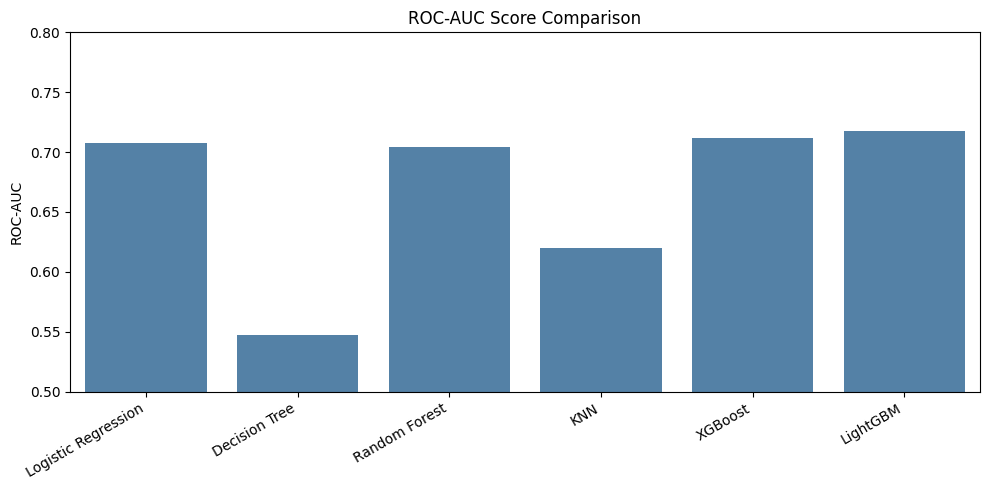

In [35]:
# ROC-AUC comparison bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x=model_comparison.index, y=model_comparison['ROC-AUC'], color='steelblue')
plt.title('ROC-AUC Score Comparison')
plt.ylabel('ROC-AUC')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.ylim(0.5, 0.80)
plt.tight_layout()
plt.show()

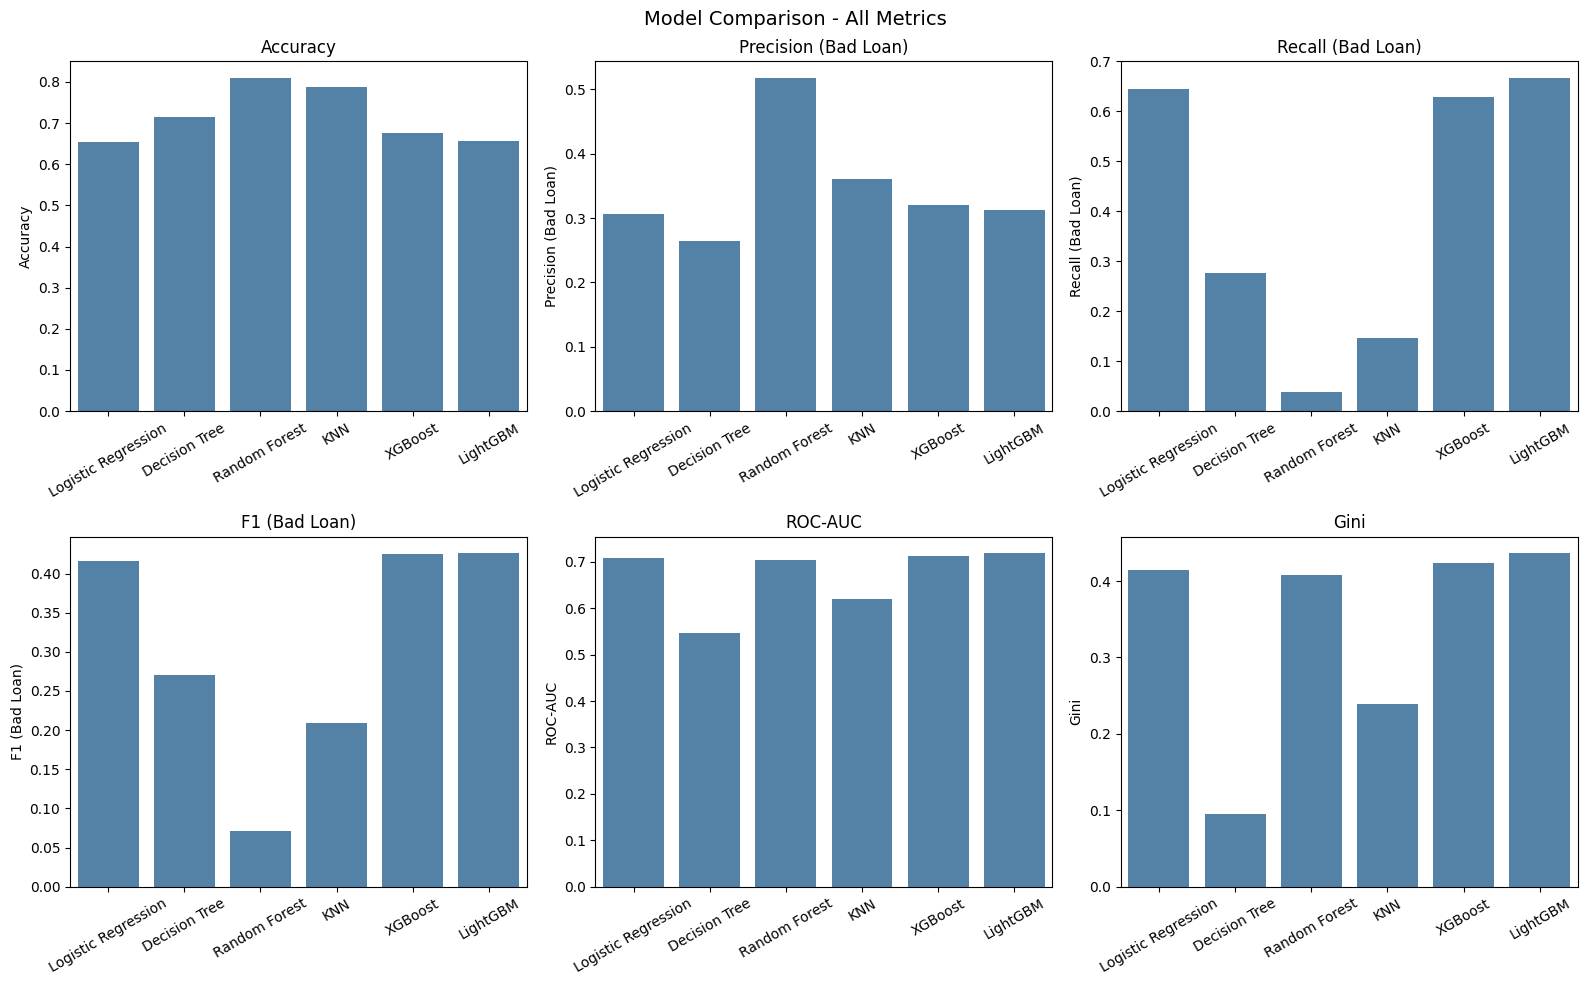

In [36]:
# All metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision (Bad Loan)', 'Recall (Bad Loan)',
           'F1 (Bad Loan)', 'ROC-AUC', 'Gini']

for i, metric in enumerate(metrics):
    sns.barplot(x=model_comparison.index, y=model_comparison[metric],
                ax=axes[i], color='steelblue')
    axes[i].set_title(metric)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Model Comparison - All Metrics', fontsize=14)
plt.tight_layout()
plt.show()

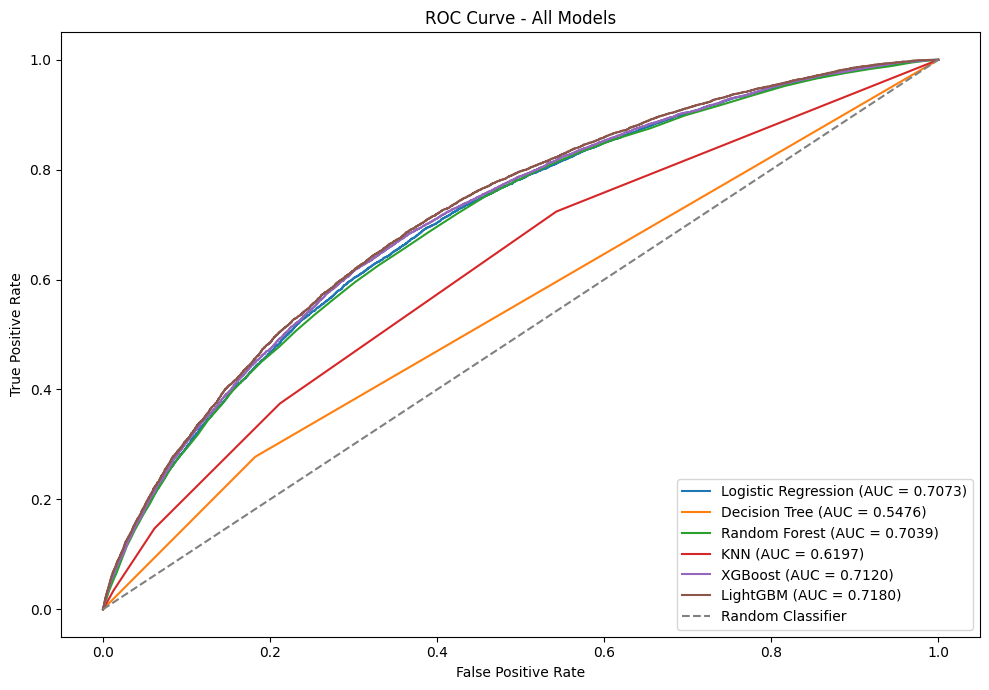

In [37]:
# ROC Curve - All models
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {auc_lgbm:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.title('ROC Curve - All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Key Findings - Model Comparison

**ROC-AUC Rankings**
LightGBM leads with the highest ROC-AUC of **0.7180**, followed by XGBoost (0.7120)
and Logistic Regression (0.7073). Both gradient boosting models outperform the remaining
traditional models in overall discriminative power.

**Gradient Boosting vs Traditional Models**
LightGBM and XGBoost consistently outperform Logistic Regression, Decision Tree, KNN,
and Random Forest across ROC-AUC, Gini, and KS Statistic. This confirms that gradient
boosting methods are better suited for this credit risk prediction problem.

**Precision vs Recall Trade-off Across All Models**
A clear trade-off pattern emerges across all models. Models with higher recall for Bad Loan
(LightGBM, XGBoost, Logistic Regression) show lower precision, while Random Forest achieves
the highest precision (0.52) but nearly fails to detect defaulters (recall = 0.04).
No single model achieves a strong balance between precision and recall for the Bad Loan class.

**Best Model by Metric**
- **ROC-AUC**: LightGBM (0.7180)
- **Gini**: LightGBM (0.4360)
- **KS Statistic**: LightGBM (0.3229)
- **Recall (Bad Loan)**: LightGBM (0.6668)
- **Precision (Bad Loan)**: Random Forest (0.5177)
- **Accuracy**: Random Forest (0.8095)

**Accuracy is a Misleading Metric**
Random Forest achieves the highest accuracy (0.8095) but misses 96% of actual defaulters
(recall = 0.04). This confirms that accuracy alone is not a reliable evaluation metric
under class imbalance and should not be used as the primary selection criterion.

**Selected Model**
LightGBM is selected as the best performing model, achieving the highest ROC-AUC (0.7180),
Gini (0.4360), KS Statistic (0.3229), and Recall for Bad Loan (0.6668) simultaneously.
It provides the most reliable and balanced performance for credit default prediction.

---

# 8. Hyperparameter Tuning

This section optimizes the LightGBM model using Optuna, a Bayesian hyperparameter
optimization framework. Unlike GridSearchCV which exhaustively searches all combinations,
Optuna intelligently explores the parameter space by learning from previous trials,
making it significantly more efficient for large datasets.

The approach includes:
- **Defining** the search space for key LightGBM hyperparameters
- **Running** 30 trials of Bayesian optimization to find the best parameter combination
- **Evaluating** the tuned model against the baseline LightGBM
- **Comparing** improvement in ROC-AUC, Gini, and KS Statistic

**Parameter Explanation:**
- `n_estimators`: number of boosting trees
- `learning_rate`: step size for each boosting iteration
- `max_depth`: maximum tree depth, controls model complexity
- `num_leaves`: maximum number of leaves per tree, key LightGBM parameter
- `min_child_samples`: minimum samples per leaf, acts as regularization
- `subsample`: fraction of training data used per iteration
- `colsample_bytree`: fraction of features used per tree
- `reg_alpha`: L1 regularization
- `reg_lambda`: L2 regularization

In [38]:
# Define objective function for Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1
    }

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_prob)

# Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest Trial  : {study.best_trial.number}")
print(f"Best ROC-AUC: {study.best_value:.4f}")
print(f"\nBest Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best trial: 8. Best value: 0.720905: 100%|██████████| 30/30 [02:45<00:00,  5.52s/it]


Best Trial  : 8
Best ROC-AUC: 0.7209

Best Parameters:
  n_estimators: 351
  learning_rate: 0.04324242090486329
  max_depth: 8
  num_leaves: 48
  min_child_samples: 59
  subsample: 0.975101126262876
  colsample_bytree: 0.6665247360211521
  reg_alpha: 0.12819163265973565
  reg_lambda: 0.22534167004557282


In [39]:
# Train tuned LightGBM with best parameters
lgbm_tuned = LGBMClassifier(
    **study.best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_tuned.fit(X_train, y_train)
print("Tuned LightGBM training completed.")

Tuned LightGBM training completed.


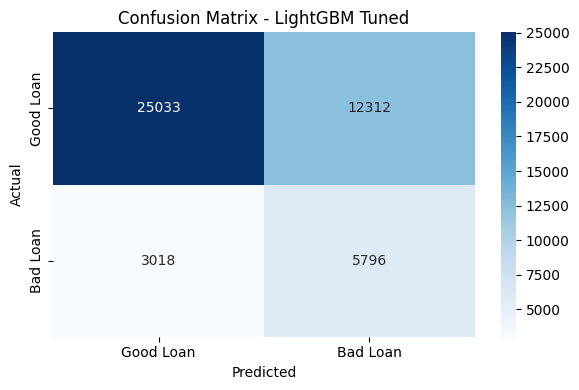

In [40]:
# Predictions
y_pred_lgbm_tuned = lgbm_tuned.predict(X_test)
y_prob_lgbm_tuned = lgbm_tuned.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_lgbm_tuned = confusion_matrix(y_test, y_pred_lgbm_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lgbm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Loan', 'Bad Loan'],
            yticklabels=['Good Loan', 'Bad Loan'])
plt.title('Confusion Matrix - LightGBM Tuned')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [41]:
# Classification Report
print("Classification Report - LightGBM Tuned")
print(classification_report(y_test, y_pred_lgbm_tuned, target_names=['Good Loan', 'Bad Loan']))

# ROC-AUC, Gini, KS Statistic
auc_lgbm_tuned = roc_auc_score(y_test, y_prob_lgbm_tuned)
gini_lgbm_tuned = 2 * auc_lgbm_tuned - 1
fpr_lgbm_tuned, tpr_lgbm_tuned, _ = roc_curve(y_test, y_prob_lgbm_tuned)
ks_lgbm_tuned = max(tpr_lgbm_tuned - fpr_lgbm_tuned)

print(f"ROC-AUC Score : {auc_lgbm_tuned:.4f}")
print(f"Gini          : {gini_lgbm_tuned:.4f}")
print(f"KS Statistic  : {ks_lgbm_tuned:.4f}")

# Improvement vs baseline
print(f"\nImprovement vs Baseline LightGBM:")
print(f"  ROC-AUC : {auc_lgbm:.4f} -> {auc_lgbm_tuned:.4f} ({(auc_lgbm_tuned - auc_lgbm)*100:+.2f}%)")
print(f"  Gini    : {gini_lgbm:.4f} -> {gini_lgbm_tuned:.4f} ({(gini_lgbm_tuned - gini_lgbm)*100:+.2f}%)")
print(f"  KS Stat : {ks_lgbm:.4f} -> {ks_lgbm_tuned:.4f} ({(ks_lgbm_tuned - ks_lgbm)*100:+.2f}%)")

Classification Report - LightGBM Tuned
              precision    recall  f1-score   support

   Good Loan       0.89      0.67      0.77     37345
    Bad Loan       0.32      0.66      0.43      8814

    accuracy                           0.67     46159
   macro avg       0.61      0.66      0.60     46159
weighted avg       0.78      0.67      0.70     46159

ROC-AUC Score : 0.7209
Gini          : 0.4418
KS Statistic  : 0.3290

Improvement vs Baseline LightGBM:
  ROC-AUC : 0.7180 -> 0.7209 (+0.29%)
  Gini    : 0.4360 -> 0.4418 (+0.59%)
  KS Stat : 0.3229 -> 0.3290 (+0.61%)


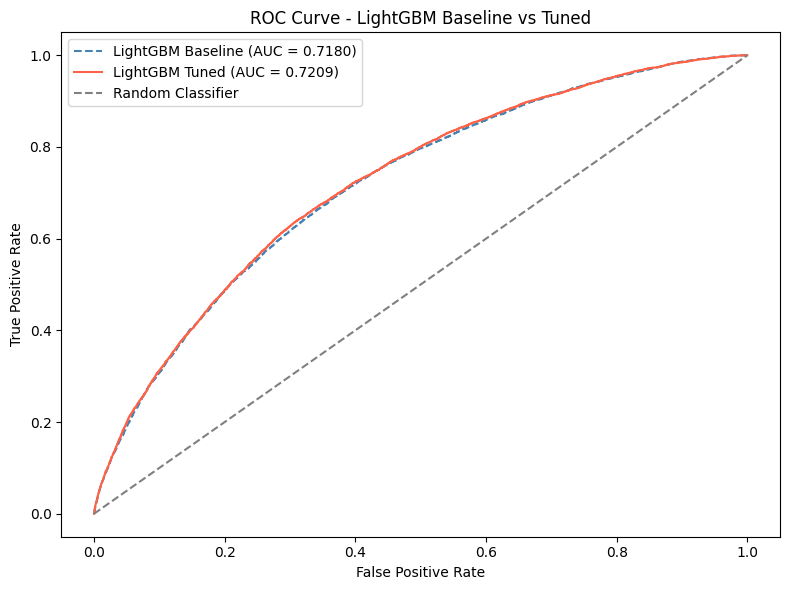

In [42]:
# ROC Curve - Baseline vs Tuned
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgbm, tpr_lgbm, color='steelblue', linestyle='--',
         label=f'LightGBM Baseline (AUC = {auc_lgbm:.4f})')
plt.plot(fpr_lgbm_tuned, tpr_lgbm_tuned, color='tomato',
         label=f'LightGBM Tuned (AUC = {auc_lgbm_tuned:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.title('ROC Curve - LightGBM Baseline vs Tuned')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()